Bibliotecile necesare

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

Citim fisierele si ne cream data frame-urile

In [2]:
train = pd.read_csv("CB_OUALD_train.csv")
test_fin = pd.read_csv("CB_OUALD_test.csv")
# pentru kaggle
#train = pd.concat([train, test_fin], axis=0, ignore_index=True)

Analiza tipului de atribute și a plajei de valori a acestora
Statistici

Atribute continue

In [3]:
features = train.select_dtypes(include='number').columns
non_null_numeric = train.select_dtypes(include='number').count()
average = train.select_dtypes(include='number').mean()
std_dev = train.select_dtypes(include='number').std()
min = train.select_dtypes(include='number').min()
max = train.select_dtypes(include='number').max()
percentile_25 = train.select_dtypes(include='number').quantile(0.25)
percentile_50 = train.select_dtypes(include='number').quantile(0.50)
percentile_75 = train.select_dtypes(include='number').quantile(0.75)
table = pd.DataFrame({
    "feature": features,
    "non_null_numeric": non_null_numeric,
    "average": average,
    "std_dev": std_dev,
    "min": min,
    "max": max,
    "percentile_25": percentile_25,
    "percentile_50": percentile_50,
    "percentile_75": percentile_75
})
table = table.round(2)
table.to_csv("stats_continuous_table.csv", index=False)

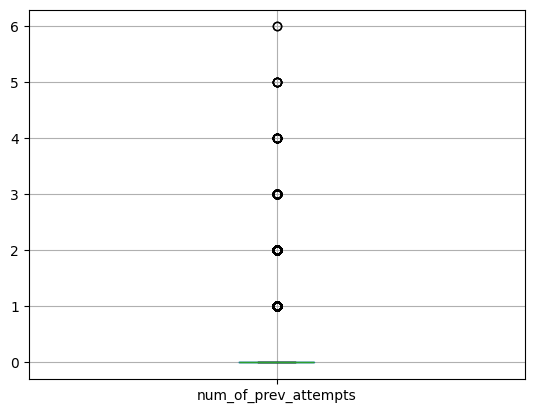

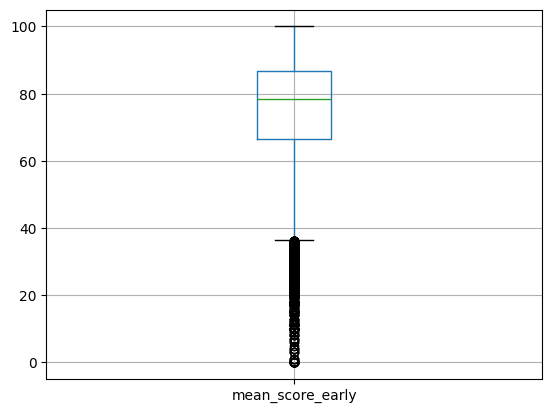

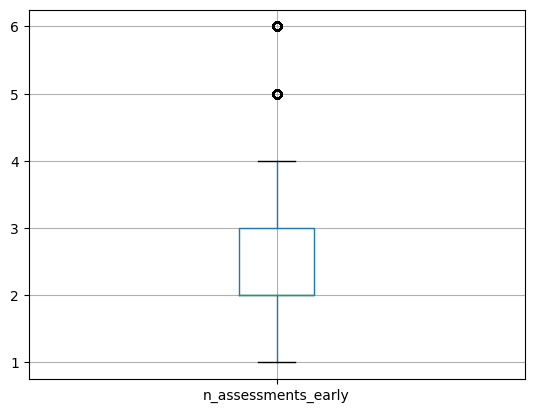

In [4]:
date = {
    'num_of_prev_attempts': train['num_of_prev_attempts']
}
df = pd.DataFrame(date)
df.boxplot()
plt.savefig("grafic_continuu1.png")
plt.show()

date = {
    'mean_score_early': train['mean_score_early']
}
df = pd.DataFrame(date)
df.boxplot()
plt.savefig("grafic_continuu2.png")
plt.show()

date = {
    'n_assessments_early': train['n_assessments_early']
}
df = pd.DataFrame(date)
df.boxplot()
plt.savefig("grafic_continuu3.png")
plt.show()

Atribute discrete

In [5]:
features = train.select_dtypes(exclude='number').columns
non_null_discrete = train.select_dtypes(exclude='number').count()
unique = train.select_dtypes(exclude='number').nunique()
table = pd.DataFrame({
    "feature": features,
    "non_null_discrete": non_null_discrete,
    "unique": unique,
})
table.to_csv("stats_discrete_table.csv", index=False)

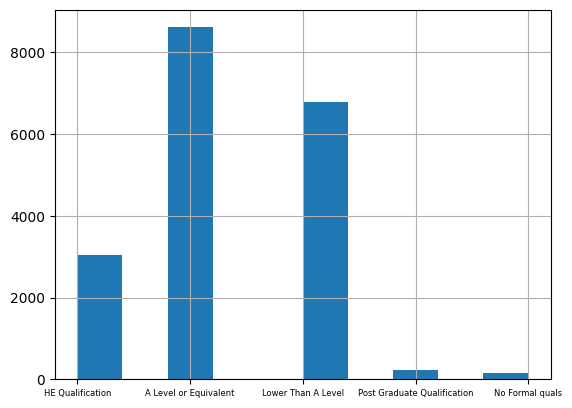

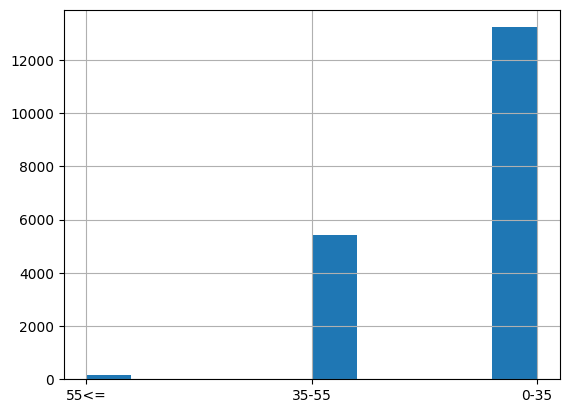

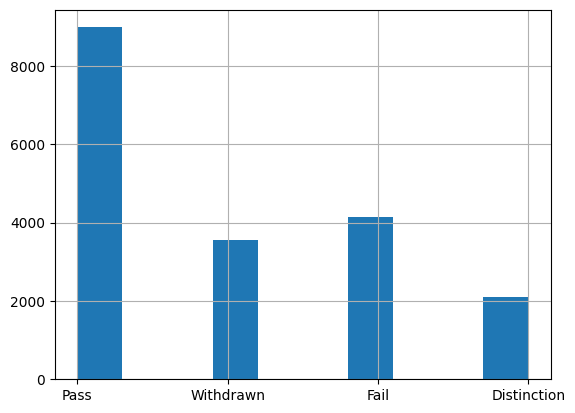

In [6]:
date = {
    'highest_education': train['highest_education']
}
df = pd.DataFrame(date)
df['highest_education'].hist()
plt.xticks(fontsize=6)
plt.savefig("grafic_discret1.png")
plt.show()

date = {
    'age_band': train['age_band']
}
df = pd.DataFrame(date)
df['age_band'].hist()
plt.savefig("grafic_discret2.png")
plt.show()

date = {
    'final_result': train['final_result']
}
df = pd.DataFrame(date)
df['final_result'].hist()
plt.savefig("grafic_discret3.png")
plt.show()

Extragem obiectivul

In [7]:
final_result = train['final_result']
final_coursework_score = train['final_coursework_score']
train = train.drop(columns=['final_result', 'final_coursework_score'])


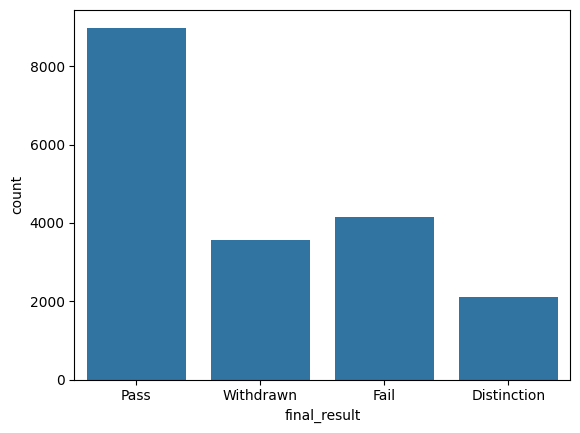

In [8]:
date = {
    'final_result': final_result
}

df = pd.DataFrame(date)

sb.countplot(data=df, x ='final_result')

plt.show()

# Analiza corelației între atribute (Pearson)

analiza între un atribut numeric și sarcina de clasificare


In [9]:
# LabelEncoder le ia alfabetic, deci nu ne ajuta
final_result_encoded = final_result.map({'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3})
coef1 = train['num_of_prev_attempts'].corr(final_result_encoded, method='pearson')
print(coef1)


-0.10536166339112116


Analiza intre un atribut categorial și sarcina de clasificare
Folosesc testul chi patrat, deoarece ambele sunt categorice

In [10]:
freq = pd.crosstab(train['age_band'], final_result)
chi2, p_value2, dof, expected = chi2_contingency(freq)
print(p_value2) # dependenta foarte puternica

4.361815349941201e-25


analiza intre un atribut numeric și sarcina de regresie

In [11]:
coef3 = train['num_of_prev_attempts'].corr(final_coursework_score, method='pearson')
print(coef3) 

-0.09032083599535008


analiza intre un atribut categorial și sarcina de regresie

In [12]:
encoder = LabelEncoder()
age_band_encoded = pd.Series(encoder.fit_transform(train['age_band']),index=train.index)
coef4 = age_band_encoded.corr(final_coursework_score, method='pearson')
print(coef4)

0.06162490478687704


Atribute redundante (puternic corelate)

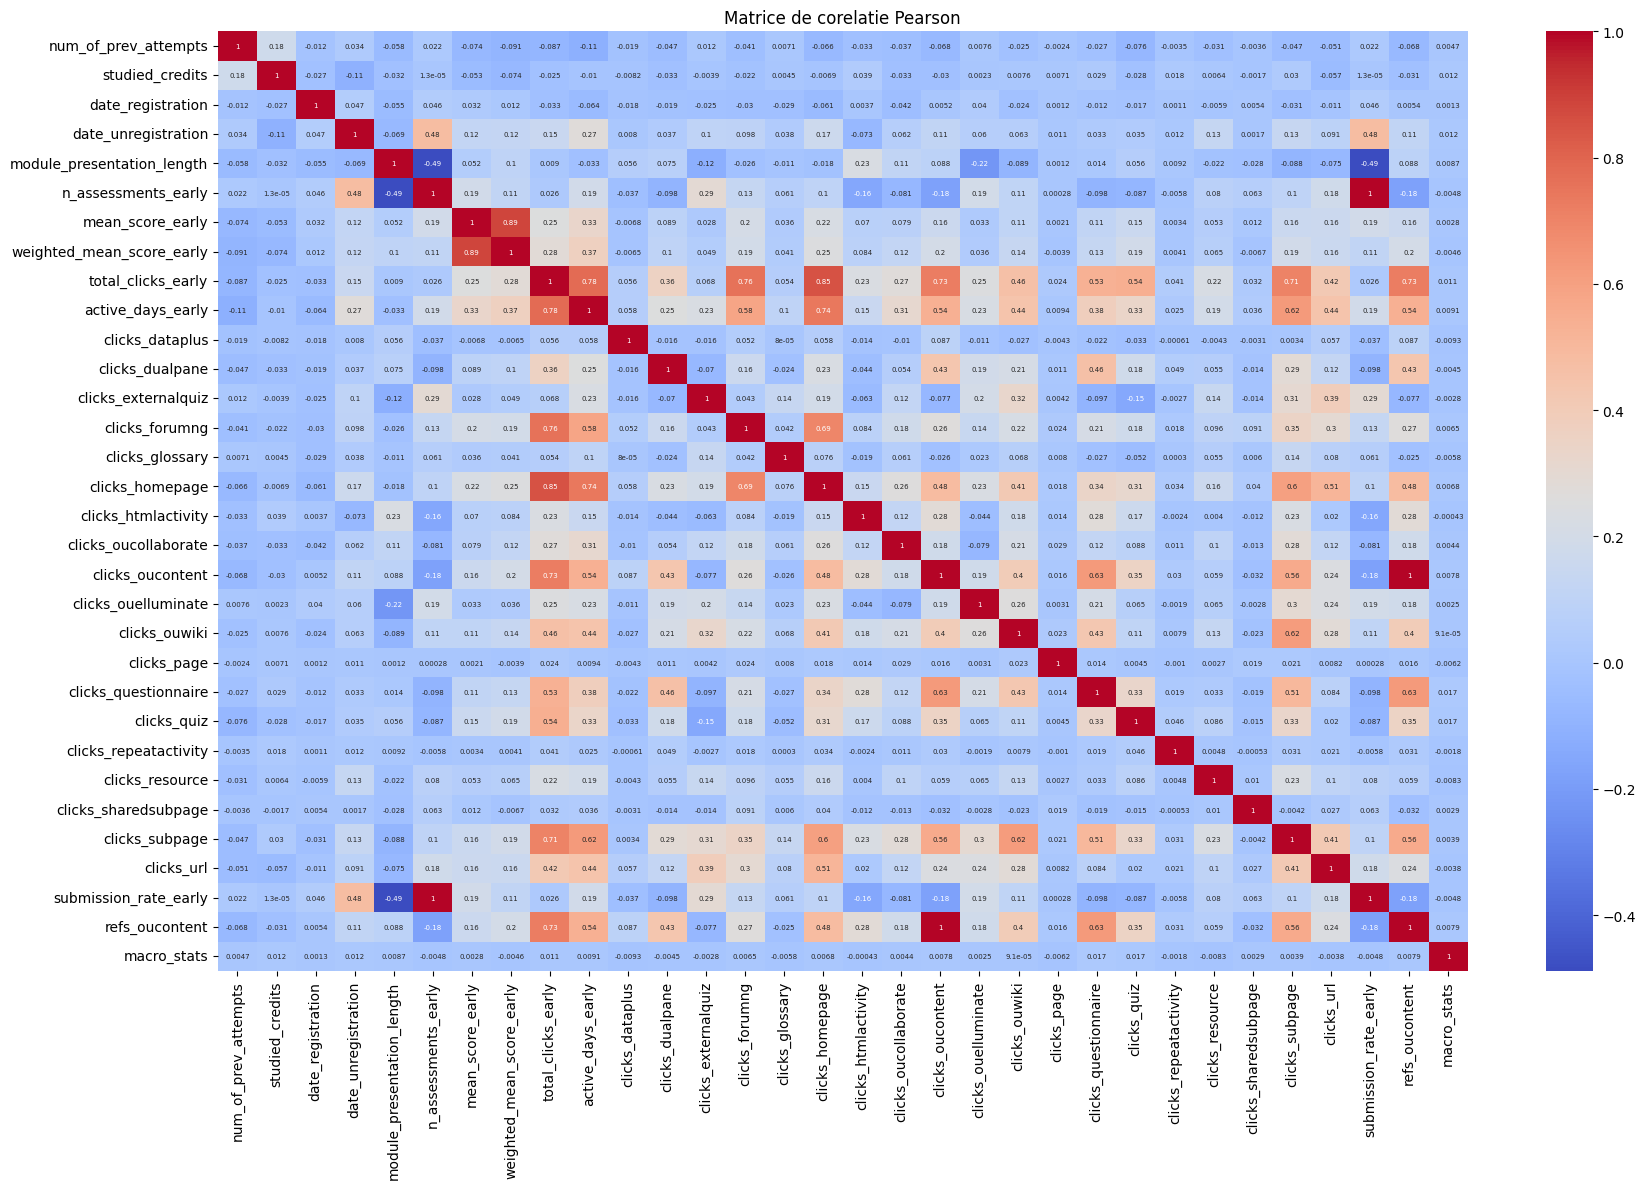

"\nfor i in range(0, len(corr_matrix)):\n    for j in range(i + 1, len(corr_matrix)):\n        if (corr_matrix.iloc[i, j] > 0.95):\n            corr1 = train[corr_matrix.columns[i]].corr(final_result_encoded, method='pearson')\n            corr2 = train[corr_matrix.columns[j]].corr(final_result_encoded, method='pearson')\n            print(corr_matrix.columns[i], corr_matrix.columns[j], corr1, corr2)\n            if (corr1 < corr2):\n                train = train.drop(columns=corr_matrix.columns[i])\n            else:\n                train = train.drop(columns=corr_matrix.columns[j])\n"

In [13]:
corr_matrix = train.corr(numeric_only=True)
plt.figure(figsize=(18, 12))

sb.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 5}
)

plt.title("Matrice de corelatie Pearson")
plt.tight_layout()
plt.savefig("matrice_corelatie.png")
plt.show()
# in practica nu ma ajuta
"""
for i in range(0, len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        if (corr_matrix.iloc[i, j] > 0.95):
            corr1 = train[corr_matrix.columns[i]].corr(final_result_encoded, method='pearson')
            corr2 = train[corr_matrix.columns[j]].corr(final_result_encoded, method='pearson')
            print(corr_matrix.columns[i], corr_matrix.columns[j], corr1, corr2)
            if (corr1 < corr2):
                train = train.drop(columns=corr_matrix.columns[i])
            else:
                train = train.drop(columns=corr_matrix.columns[j])
"""

In [14]:
# dau drop la coloana macro_stats deoarece e noise si nu ma ajuta
corr1 = train['macro_stats'].corr(final_result_encoded, method='pearson')
print(corr1)
corr2 = train['macro_stats'].corr(final_coursework_score, method='pearson')
print(corr2)
train = train.drop(columns='macro_stats')

0.0001865702180350986
-0.006174492329073312


Imputarea valorilor lipsă

pentru atribute numerice

In [15]:
# data_unregister ma ajuta mult deorace imi spune cine da pass (0 = pass, 1 altfel)
train['date_unregistration'] = train['date_unregistration'].notna().astype(int)

numeric_imputer = SimpleImputer(strategy='mean')
num_cols = train.select_dtypes(include='number').columns
train[num_cols] = numeric_imputer.fit_transform(train[num_cols])

atribute categoriale

In [16]:
categorial_imputer = SimpleImputer(strategy='most_frequent')
non_num_cols = train.select_dtypes(exclude='number').columns
train[non_num_cols] = categorial_imputer.fit_transform(train[non_num_cols])

outliers

z-score

In [17]:
average_after = train.select_dtypes(include='number').mean()
std_dev_after = train.select_dtypes(include='number').std()
percentile_25_after = train.select_dtypes(include='number').quantile(0.25)
percentile_50_after = train.select_dtypes(include='number').quantile(0.50)
percentile_75_after = train.select_dtypes(include='number').quantile(0.75)
# pastrez coloana date_unregistration, deoarece ma ajuta transformarea de mai sus si nu vreau sa fie afectata
ouliers_cols = train.select_dtypes(include='number').columns.drop('date_unregistration')
#z = (train[ouliers_cols] - average_after[ouliers_cols]) / std_dev_after[ouliers_cols]
#bad_z = (z < -3) | (z > 3)
#train[ouliers_cols] = train[ouliers_cols].mask(bad_z, percentile_50_after[ouliers_cols], axis=1)

percentile

In [18]:
IQR = percentile_75_after - percentile_25_after
bad_per = (train[ouliers_cols] < percentile_25_after[ouliers_cols] - 1.5 * IQR[ouliers_cols]) | (train[ouliers_cols] > percentile_75_after[ouliers_cols] + 1.5 * IQR[ouliers_cols])
train[ouliers_cols] = train[ouliers_cols].mask(bad_per, percentile_50_after[ouliers_cols], axis=1)

transform atributele categorice in numerice

In [17]:
hot_encoder = OneHotEncoder(sparse_output=False)
encoded = hot_encoder.fit_transform(train[train.select_dtypes(exclude='number').columns])
train = pd.concat([train.select_dtypes(include='number').reset_index(drop=True), pd.DataFrame(encoded, columns=hot_encoder.get_feature_names_out())], axis=1)

standardizarea datelor

In [18]:
scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])

impart setul in 80% antrenare si 20% testare

In [19]:
X_train, X_test, y_train, y_test = train_test_split(train, final_result, test_size=0.2, random_state=1)

In [ ]:
# Baseline (cu tot cu imputare, out liers etc.)

In [20]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.6689710183461846
Precision: 0.6711502447806016
Recall: 0.6689710183461846
F1 Score: 0.6696676657594025


Variez hiperparametrul max_depth

In [21]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Accuracy: 0.7365062483382079
Precision: 0.7534677016384124
Recall: 0.7365062483382079
F1 Score: 0.6875170513156539


Folosesc RandomForest alegand atent hiperparametrii

In [22]:
model = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Kaggle Score: 0.73")

model = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=1)
model.fit(train, final_result)

y_test = test_fin['final_result']
test = test_fin.drop(columns=['final_result', 'final_coursework_score'], errors='ignore')

test = test.drop(columns=['macro_stats'], errors='ignore')
test['date_unregistration'] = test['date_unregistration'].notna().astype(int)

test[num_cols] = numeric_imputer.transform(test[num_cols])
test[non_num_cols] = categorial_imputer.transform(test[non_num_cols])

#bad_per_test = (test[ouliers_cols] < percentile_25_after[ouliers_cols] - 1.5 * IQR[ouliers_cols]) | (test[ouliers_cols] > percentile_75_after[ouliers_cols] + 1.5 * IQR[ouliers_cols])
#test[ouliers_cols] = test[ouliers_cols].mask(bad_per_test, percentile_50_after[ouliers_cols], axis=1)

encoded_test = hot_encoder.transform(test[non_num_cols])
test = pd.concat([test[num_cols].reset_index(drop=True), pd.DataFrame(encoded_test, columns=hot_encoder.get_feature_names_out())], axis=1)

test[num_cols] = scaler.transform(test[num_cols])

test = test[train.columns]

y_pred = model.predict(test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.7561818665248604
Precision: 0.7563836819835911
Recall: 0.7561818665248604
F1 Score: 0.7301156535330219
Kaggle Score: 0.73
Accuracy: 0.7597872340425532
Precision: 0.7698750921730843
Recall: 0.7597872340425532
F1 Score: 0.7374878934382602


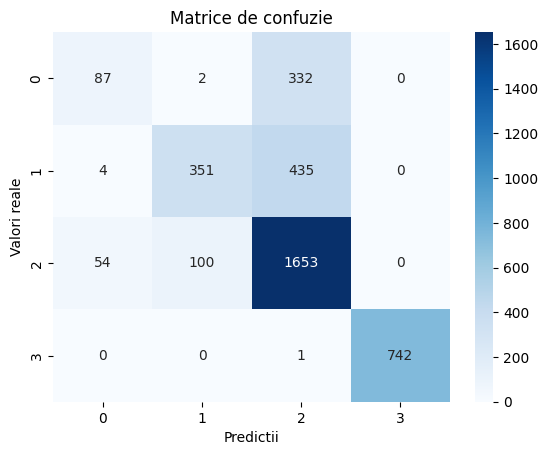

In [27]:
conf_matrix = confusion_matrix(y_test, y_pred)
sb.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predictii")
plt.ylabel("Valori reale")
plt.title("Matrice de confuzie")
plt.savefig("matrice_confuzie.png")
plt.show()

Regresie

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(train, final_coursework_score, test_size=0.2, random_state=1)
train_errs = []
test_errs = []
for n in range(1, 301, 10):
#model = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=1)
    model = RandomForestRegressor(n_estimators=n, max_depth=15, random_state=1)
    model.fit(X_train, y_train)
#model.fit(X_train, y_train)
    y_pred1 = model.predict(X_train)
    y_pred2 = model.predict(X_test)
#y_pred = model.predict(X_test)
    # forteaza notele sa fie intre 0 si 100 (sub 0 => 0 si > 100 => 100)
#y_pred = np.clip(y_pred, 0, 100)
    y_pred1 = np.clip(y_pred1, 0, 100)
    y_pred2 = np.clip(y_pred2, 0, 100)
# mae
#mae = mean_absolute_error(y_test, y_pred)  
#print("MAE: ", mae)

# mse
#mse = mean_squared_error(y_test, y_pred)
#print("MSE: ", mse)
    mse1 = mean_squared_error(y_train, y_pred1)
    mse2 = mean_squared_error(y_test, y_pred2)
    train_errs.append(mse1)
    test_errs.append(mse2)

# rmse
#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
##print("RMSE: ", rmse)

# r^2
#r2 = r2_score(y_test, y_pred)
#print("R2: ", r2)
    #print("Kaggle Score: 90.42")
#model = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=1)
#model .fit(train, final_coursework_score)

#y_test = test_fin['final_coursework_score']

#y_pred = model.predict(test)

#y_pred = np.clip(y_pred, 0, 100)
#print("MAE: ", mean_absolute_error(y_test, y_pred))
#print("MSE: ", mean_squared_error(y_test, y_pred))
#print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
#print("R2: ", r2_score(y_test, y_pred))

KeyboardInterrupt: 

Grafic regresie

In [ ]:
estimators = list(range(1, 301, 20))
plt.figure(figsize=(9, 6))
plt.plot(estimators, train_errs, label="Train Error")
plt.plot(estimators, test_errs, label = "Test Error")
plt.xlabel("n_estimators")
plt.ylabel("MSE")
plt.xticks(estimators)
plt.tick_params(axis='both', labelsize=7)
plt.legend(loc='upper left')
plt.savefig("grafic_regresie.png")
plt.show()

NameError: name 'train_errs' is not defined